In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score,
                             silhouette_score)
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering


# 1. Data Loading and Initial Configuration

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
CSV_FILE_PATH = './../data/bee_features.csv'
TARGET_COLUMN = 'bug type'
FEATURES_TO_DROP_FOR_MODELING = ['ID', 'bug type', 'species']
MIN_SAMPLES_PER_CLASS_FOR_STRATIFICATION = 2
TEST_SET_SIZE_INTERNAL = 0.25
RANDOM_STATE = 42

In [11]:
df_original = pd.read_csv(CSV_FILE_PATH)
print(f"Original dataset loaded successfully. Shape: {df_original.shape}")
print("\nFirst 5 rows of the original dataset:")
display(df_original.head())
print("\nDataset Info:")
df_original.info()

Original dataset loaded successfully. Shape: (249, 25)

First 5 rows of the original dataset:


,ID,R_min,R_max,R_mean,R_median,R_std,G_min,G_max,G_mean,G_median,...,B_std,pixel_ratio,area,perimeter,circularity_laplacian,bounding_box_ratio,center_mass_x,center_mass_y,bug type,species
0,1,5,208,68.085745,56.0,47.955399,3,199,54.882747,37.0,...,36.250747,0.007428,178273,8998,0.027670,1.223881,3035.244911,2222.120394,Bee,Apis mellifera
1,2,2,248,63.786498,55.0,42.153508,2,251,52.079650,34.0,...,34.617117,0.008553,205272,9494,0.028618,1.514286,3032.674607,1698.048360,Bee,Apis mellifera
2,3,3,255,107.176333,114.0,58.771359,0,255,87.794710,86.0,...,54.823596,0.022093,530235,11818,0.047708,1.060606,2714.310953,1137.948478,Bee,Apis mellifera
3,4,5,219,87.588243,88.0,46.322587,3,213,71.031852,61.0,...,37.445621,0.013187,316497,12385,0.025929,1.308511,3486.890675,2223.213951,Bee,Apis mellifera
4,5,6,255,123.177003,134.0,62.355944,0,250,100.897964,91.0,...,60.624962,0.009165,219951,7870,0.044626,1.200000,2867.283645,2195.199194,Bee,Apis mellifera



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     249 non-null    int64  
 1   R_min                  249 non-null    int64  
 2   R_max                  249 non-null    int64  
 3   R_mean                 249 non-null    float64
 4   R_median               249 non-null    float64
 5   R_std                  249 non-null    float64
 6   G_min                  249 non-null    int64  
 7   G_max                  249 non-null    int64  
 8   G_mean                 249 non-null    float64
 9   G_median               249 non-null    float64
 10  G_std                  249 non-null    float64
 11  B_min                  249 non-null    int64  
 12  B_max                  249 non-null    int64  
 13  B_mean                 249 non-null    float64
 14  B_median               249 non-null    floa

## Pre-processing and Filtering for Stratification

In [12]:
df_processed = df_original.copy()

# 1. Identify and filter classes with too few samples. Stuff like wasp or dragonfly
original_class_counts = df_processed[TARGET_COLUMN].value_counts()
print("\nOriginal class distribution ('bug type'):")
print(original_class_counts)

classes_to_remove = original_class_counts[original_class_counts < MIN_SAMPLES_PER_CLASS_FOR_STRATIFICATION].index

if not classes_to_remove.empty:
    print(f"\nWarning: The following classes in '{TARGET_COLUMN}' have fewer than {MIN_SAMPLES_PER_CLASS_FOR_STRATIFICATION} samples and will be removed:")
    for cls_name in classes_to_remove:
        print(f"- Class '{cls_name}' (count: {original_class_counts[cls_name]})")
    df_processed = df_processed[~df_processed[TARGET_COLUMN].isin(classes_to_remove)].copy()
    print(f"Shape after filtering rare classes: {df_processed.shape}")

    if df_processed.empty or len(df_processed[TARGET_COLUMN].unique()) < 2:
        print("\nError: Filtering removed too many samples or distinct classes. Cannot proceed with modeling.")
        # In a notebook, you'd likely stop here.
        raise SystemExit("Exiting due to insufficient data after filtering.")
else:
    print(f"\nAll classes in '{TARGET_COLUMN}' have at least {MIN_SAMPLES_PER_CLASS_FOR_STRATIFICATION} samples. No filtering needed for this step.")



Original class distribution ('bug type'):
bug type
Bee          115
Bumblebee    100
Butterfly     15
Hover fly      9
Wasp           9
Dragonfly      1
Name: count, dtype: int64

- Class 'Dragonfly' (count: 1)
Shape after filtering rare classes: (248, 25)


In [13]:
# 2. Prepare features (X_features_full) and categorical target (y_categorical_full) from the PROCESSED DataFrame
X_features_full_df = df_processed.drop(columns=FEATURES_TO_DROP_FOR_MODELING) # Keep as DataFrame for feature names
y_categorical_full = df_processed[TARGET_COLUMN]

# 3. Fit LabelEncoder on the full (filtered) categorical target
# This encoder and its classes will be used throughout for consistency
label_encoder = LabelEncoder()
y_encoded_full = label_encoder.fit_transform(y_categorical_full)
MODELING_CLASS_NAMES = label_encoder.classes_

print(f"\nTarget variable '{TARGET_COLUMN}' encoded for modeling.")
print(f"Classes used for modeling: {MODELING_CLASS_NAMES}")
print(f"Encoded mapping: {dict(zip(MODELING_CLASS_NAMES, range(len(MODELING_CLASS_NAMES))))}")

# 4. Fit StandardScaler on the full (filtered) features
# This scaler will be used for all transformations
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_features_full_df)
print("\nFeatures scaled using StandardScaler (fit on full processed data).")
# Store feature names for the correlation circle. It is completely optional and it looks like shit but I wanted to see what we would have. DO NOT USE IN THE RAPPORT !
feature_names = X_features_full_df.columns.tolist()


Target variable 'bug type' encoded for modeling.
Classes used for modeling: ['Bee' 'Bumblebee' 'Butterfly' 'Hover fly' 'Wasp']
Encoded mapping: {'Bee': 0, 'Bumblebee': 1, 'Butterfly': 2, 'Hover fly': 3, 'Wasp': 4}

Features scaled using StandardScaler (fit on full processed data).


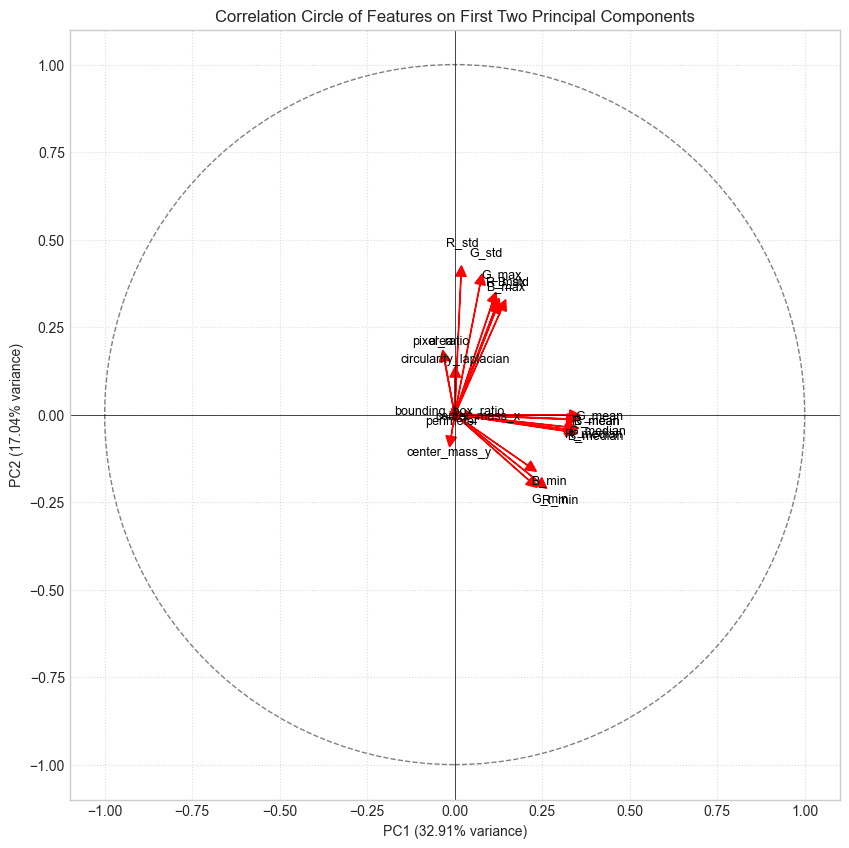

In [14]:
pca_corr = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_corr = pca_corr.fit_transform(X_scaled_full) # We don't strictly need X_pca_corr for the circle, but fitting is necessary

# --- Create the Correlation Circle Plot ---
# Again this part is not required so WE WILL NOT USE IT IN THE RAPPORT.

pcs = pca_corr.components_

plt.figure(figsize=(10, 10))
# Plot a unit circle
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Plot arrows for each feature
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, pcs[0, i], pcs[1, i],
              head_width=0.03, head_length=0.03, fc='red', ec='red',
              length_includes_head=True)
    plt.text(pcs[0, i] * 1.15, pcs[1, i] * 1.15, feature, color='black',
             ha='center', va='center', fontsize=9)

plt.xlim([-1.1, 1.1])
plt.ylim([-1.1, 1.1])
plt.xlabel(f"PC1 ({pca_corr.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_corr.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.title('Correlation Circle of Features on First Two Principal Components')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


In [15]:
# --- Split Data for Training and Internal Testing ---
df_train_set, df_test_internal_set = train_test_split(
    df_processed,
    test_size=TEST_SET_SIZE_INTERNAL,
    random_state=RANDOM_STATE,
    stratify=df_processed[TARGET_COLUMN]
)

# Prepare training data arrays
X_train_features_df = df_train_set.drop(columns=FEATURES_TO_DROP_FOR_MODELING)
X_train = scaler.transform(X_train_features_df)
y_train = label_encoder.transform(df_train_set[TARGET_COLUMN])

# Prepare internal test data arrays
X_test_internal_features_df = df_test_internal_set.drop(columns=FEATURES_TO_DROP_FOR_MODELING)
X_test_internal = scaler.transform(X_test_internal_features_df)
y_test_internal = label_encoder.transform(df_test_internal_set[TARGET_COLUMN])
test_ids_internal = df_test_internal_set['ID'].values # IDs for the demo CSV

print(f"\nData split into training and internal test sets:")
print(f"Training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Internal test set shape: X_test_internal {X_test_internal.shape}, y_test_internal {y_test_internal.shape}")
print(f"Number of IDs for internal test CSV: {len(test_ids_internal)}")



Data split into training and internal test sets:
Training set shape: X_train (186, 22), y_train (186,)
Internal test set shape: X_test_internal (62, 22), y_test_internal (62,)
Number of IDs for internal test CSV: 62


In [17]:

# --- Helper function to evaluate supervised models ---
def evaluate_supervised_model(model, X_train_data, y_train_data, X_test_data, y_test_data,
                              global_label_encoder,
                              all_modeling_class_names,
                              model_name="Model"):
    print(f"\n--- Evaluating {model_name} ---")
    model.fit(X_train_data, y_train_data)

    # Predictions and evaluation on training data
    y_train_pred = model.predict(X_train_data)
    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    print(f"\nTraining Data Performance for {model_name}:")
    print(f"Accuracy: {train_accuracy:.4f}")
    print("Classification Report (Training):")

    # Get labels and names present in this specific split for the report
    report_labels_train = np.unique(np.concatenate((y_train_data, y_train_pred)))
    report_target_names_train = global_label_encoder.inverse_transform(report_labels_train)
    print(classification_report(y_train_data, y_train_pred, labels=report_labels_train,
                                target_names=report_target_names_train, zero_division=0))

    # Predictions and evaluation on test data
    y_test_pred = model.predict(X_test_data)
    test_accuracy = accuracy_score(y_test_data, y_test_pred)
    print(f"\nInternal Test Data Performance for {model_name}:")
    print(f"Accuracy: {test_accuracy:.4f}")
    print("Classification Report (Internal Test):")

    report_labels_test = np.unique(np.concatenate((y_test_data, y_test_pred)))
    report_target_names_test = global_label_encoder.inverse_transform(report_labels_test)
    print(classification_report(y_test_data, y_test_pred, labels=report_labels_test,
                                target_names=report_target_names_test, zero_division=0))

    print("Confusion Matrix (Internal Test):")
    # For CM, use all known classes from initial filtering for consistent matrix size and correct labels
    cm_plot_labels_encoded = range(len(all_modeling_class_names))
    cm = confusion_matrix(y_test_data, y_test_pred, labels=cm_plot_labels_encoded)

    plt.figure(figsize=(max(8, len(all_modeling_class_names)*0.8), max(6, len(all_modeling_class_names)*0.7)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=all_modeling_class_names, yticklabels=all_modeling_class_names)
    plt.title(f'Confusion Matrix for {model_name} (Internal Test)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    return model, y_test_pred


In [18]:

# --- Helper function to evaluate clustering models ---
# Note: Clustering is typically applied to the full dataset (X_scaled_full) and evaluated against y_encoded_full
# It also it is suppoed to work way better with our dataset, having a way better accuracy.
def evaluate_clustering_model(model, X_data_full_scaled, y_data_full_encoded, model_name="Clustering Model"):
    print(f"\n--- Evaluating {model_name} ---")
    num_true_classes = len(np.unique(y_data_full_encoded))

    if isinstance(model, KMeans):
        if num_true_classes < 1:
            print("KMeans: No classes to cluster. Skipping.")
            return None
        model.n_clusters = max(1, num_true_classes)
        print(f"KMeans: Setting n_clusters to {model.n_clusters}")
    elif isinstance(model, AgglomerativeClustering):
        if model.n_clusters is None: # If n_clusters not explicitly set, derive it
            model.n_clusters = max(1, num_true_classes) # Default to 1 if < 2 classes
        print(f"AgglomerativeClustering: Setting n_clusters to {model.n_clusters}")

    cluster_labels = model.fit_predict(X_data_full_scaled)
    print(f"\nClustering Performance for {model_name} (evaluated against true '{TARGET_COLUMN}' labels):")
    y_data_flat = np.array(y_data_full_encoded).ravel()
    cluster_labels_flat = np.array(cluster_labels).ravel()

    if len(y_data_flat) != len(cluster_labels_flat):
        print("Error: Mismatch in length for clustering evaluation. Skipping metrics.")
        return cluster_labels

    # External metrics (comparing to true labels)
    if len(np.unique(y_data_flat)) > 1 and len(np.unique(cluster_labels_flat)) > 1:
        ari = adjusted_rand_score(y_data_flat, cluster_labels_flat)
        nmi = normalized_mutual_info_score(y_data_flat, cluster_labels_flat)
        homogeneity = homogeneity_score(y_data_flat, cluster_labels_flat)
        completeness = completeness_score(y_data_flat, cluster_labels_flat)
        v_measure = v_measure_score(y_data_flat, cluster_labels_flat)
        print(f"Adjusted Rand Index (ARI): {ari:.4f}")
        print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
        print(f"Homogeneity: {homogeneity:.4f}")
        print(f"Completeness: {completeness:.4f}")
        print(f"V-measure: {v_measure:.4f}")
    else:
        print("Skipping some external clustering metrics (ARI, NMI, etc.) as there's only one true class or one cluster found.")

    # Internal metric (Silhouette Score)
    if len(np.unique(cluster_labels_flat)) > 1 and X_data_full_scaled.shape[0] > 1:
        try:
            silhouette = silhouette_score(X_data_full_scaled, cluster_labels_flat)
            print(f"Silhouette Score: {silhouette:.4f}")
        except ValueError as e:
            print(f"Could not calculate Silhouette Score: {e}")
    else:
        print("Silhouette Score: Not applicable (not enough distinct clusters or samples).")
    return cluster_labels


--- Supervised: Logistic Regression ---

--- Evaluating Logistic Regression ---

Training Data Performance for Logistic Regression:
Accuracy: 0.8226
Classification Report (Training):
              precision    recall  f1-score   support

         Bee       0.84      0.88      0.86        86
   Bumblebee       0.80      0.85      0.83        75
   Butterfly       0.82      0.82      0.82        11
   Hover fly       1.00      0.14      0.25         7
        Wasp       1.00      0.43      0.60         7

    accuracy                           0.82       186
   macro avg       0.89      0.63      0.67       186
weighted avg       0.83      0.82      0.81       186


Internal Test Data Performance for Logistic Regression:
Accuracy: 0.8065
Classification Report (Internal Test):
              precision    recall  f1-score   support

         Bee       0.84      0.90      0.87        29
   Bumblebee       0.82      0.92      0.87        25
   Butterfly       0.50      0.25      0.33        

C:\JuniorISEP\PoC\PoC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


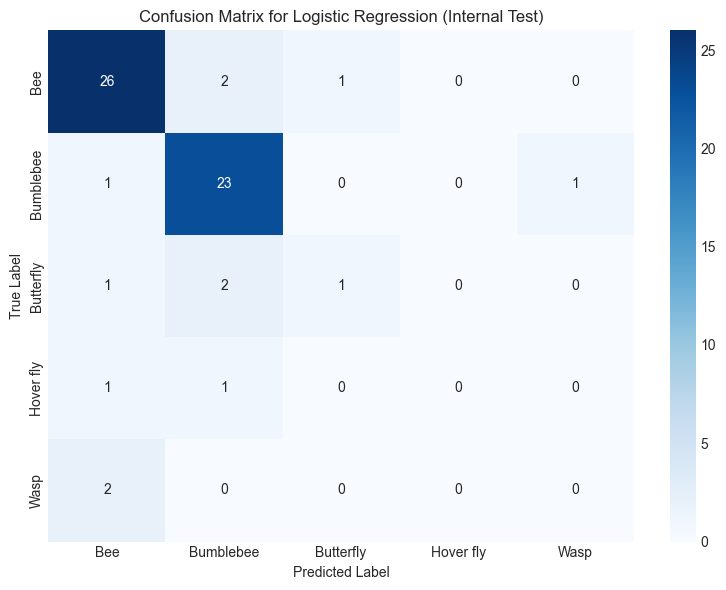

In [19]:
# --- Method 1.1: Logistic Regression ---
print("\n--- Supervised: Logistic Regression ---")
log_reg = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=RANDOM_STATE, max_iter=1000)
trained_log_reg, _ = evaluate_supervised_model(log_reg, X_train, y_train, X_test_internal, y_test_internal,
                                               label_encoder, MODELING_CLASS_NAMES, "Logistic Regression")


--- Supervised: Support Vector Machine (SVC) ---

--- Evaluating Support Vector Machine (SVC) ---

Training Data Performance for Support Vector Machine (SVC):
Accuracy: 0.8226
Classification Report (Training):
              precision    recall  f1-score   support

         Bee       0.79      0.92      0.85        86
   Bumblebee       0.84      0.85      0.85        75
   Butterfly       1.00      0.91      0.95        11
   Hover fly       0.00      0.00      0.00         7
        Wasp       0.00      0.00      0.00         7

    accuracy                           0.82       186
   macro avg       0.53      0.54      0.53       186
weighted avg       0.76      0.82      0.79       186


Internal Test Data Performance for Support Vector Machine (SVC):
Accuracy: 0.7742
Classification Report (Internal Test):
              precision    recall  f1-score   support

         Bee       0.76      0.86      0.81        29
   Bumblebee       0.79      0.88      0.83        25
   Butterfly   

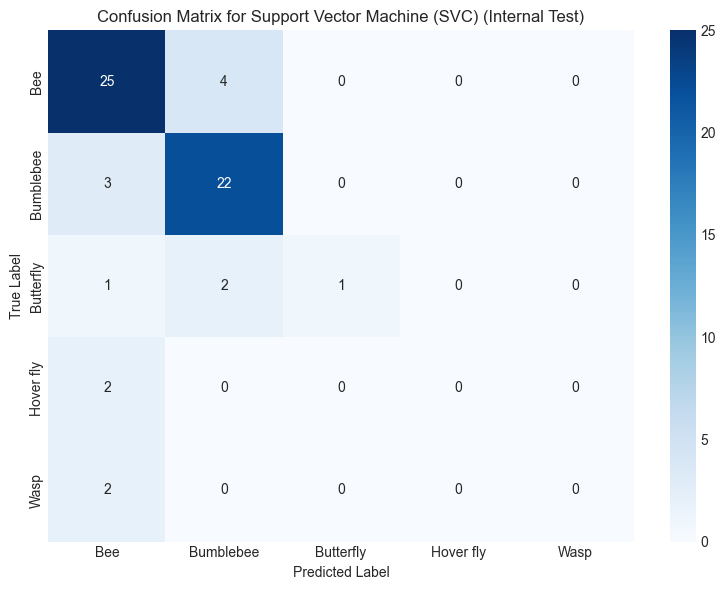

In [20]:
# --- Method 1.2: Support Vector Machine (SVC) ---
print("\n--- Supervised: Support Vector Machine (SVC) ---")
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True)
trained_svc, _ = evaluate_supervised_model(svc_model, X_train, y_train, X_test_internal, y_test_internal,
                                           label_encoder, MODELING_CLASS_NAMES, "Support Vector Machine (SVC)")


--- Supervised Ensemble: Random Forest ---

--- Evaluating Random Forest Classifier ---

Training Data Performance for Random Forest Classifier:
Accuracy: 1.0000
Classification Report (Training):
              precision    recall  f1-score   support

         Bee       1.00      1.00      1.00        86
   Bumblebee       1.00      1.00      1.00        75
   Butterfly       1.00      1.00      1.00        11
   Hover fly       1.00      1.00      1.00         7
        Wasp       1.00      1.00      1.00         7

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186


Internal Test Data Performance for Random Forest Classifier:
Accuracy: 0.7419
Classification Report (Internal Test):
              precision    recall  f1-score   support

         Bee       0.77      0.83      0.80        29
   Bumblebee       0.70      0.84      0.76        25
   Butterfly       1.00      0.25

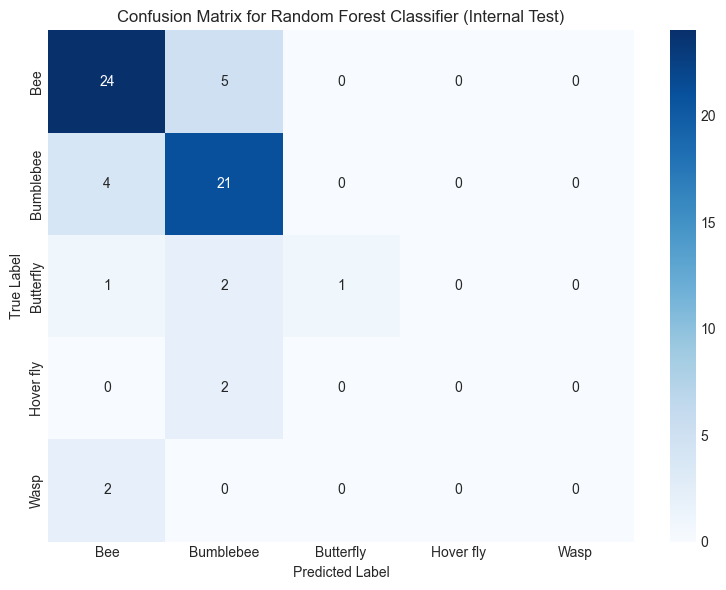

In [21]:
# --- Method 2.1: Random Forest Classifier ---
print("\n--- Supervised Ensemble: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=10, class_weight='balanced')
trained_rf, _ = evaluate_supervised_model(rf_model, X_train, y_train, X_test_internal, y_test_internal,
                                          label_encoder, MODELING_CLASS_NAMES, "Random Forest Classifier")

In [24]:
# --- Method 3.1: K-Means Clustering ---
print("\n\n--- Clustering Methods (Applied to full processed data) ---")
print("\n--- Clustering: K-Means ---")
kmeans = KMeans(random_state=RANDOM_STATE, n_init='auto')
evaluate_clustering_model(kmeans, X_scaled_full, y_encoded_full, "K-Means Clustering")



--- Clustering Methods (Applied to full processed data) ---

--- Clustering: K-Means ---

--- Evaluating K-Means Clustering ---
KMeans: Setting n_clusters to 5

Clustering Performance for K-Means Clustering (evaluated against true 'bug type' labels):
Adjusted Rand Index (ARI): 0.0880
Normalized Mutual Information (NMI): 0.1373
Homogeneity: 0.1564
Completeness: 0.1223
V-measure: 0.1373
Silhouette Score: 0.1608


array([2, 0, 3, 2, 4, 2, 2, 2, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4,
       4, 0, 4, 3, 4, 4, 3, 4, 4, 3, 0, 0, 2, 4, 4, 4, 0, 2, 4, 4, 4, 4,
       0, 4, 4, 4, 1, 4, 4, 4, 4, 4, 2, 0, 0, 0, 0, 4, 2, 2, 3, 2, 2, 3,
       3, 4, 0, 0, 0, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 3, 3, 2, 3, 3, 2, 2,
       0, 3, 3, 0, 3, 0, 3, 3, 2, 0, 0, 3, 0, 3, 3, 3, 0, 4, 0, 2, 0, 0,
       3, 0, 0, 0, 0, 0, 0, 4, 3, 0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 3, 0, 3,
       3, 3, 0, 3, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 3, 4, 4, 1, 2,
       4, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 3, 4,
       3, 4, 4, 4, 1, 4, 1, 4, 4, 1, 1, 3, 0, 1, 1, 4, 3, 0, 0, 0, 0, 3,
       0, 2, 3, 0, 2, 4, 1, 1, 0, 0, 3, 0, 4, 0, 0, 3, 4, 4, 3, 3, 3, 3,
       1, 4, 4, 3, 3, 3, 0, 3, 1, 1, 4, 4, 3, 3, 3, 3, 2, 3, 2, 2, 4, 2,
       0, 2, 0, 0, 4, 3], dtype=int32)

In [23]:
# --- Method 3.2: Agglomerative Hierarchical Clustering ---
print("\n--- Clustering: Agglomerative Clustering ---")
# n_clusters will be set similarly by the helper function
num_clusters_for_agg = len(MODELING_CLASS_NAMES) if len(MODELING_CLASS_NAMES) >=1 else 1
agglomerative = AgglomerativeClustering(n_clusters=num_clusters_for_agg, metric='euclidean', linkage='ward')
evaluate_clustering_model(agglomerative, X_scaled_full, y_encoded_full, "Agglomerative Clustering")


--- Clustering: Agglomerative Clustering ---

--- Evaluating Agglomerative Clustering ---
AgglomerativeClustering: Setting n_clusters to 5

Clustering Performance for Agglomerative Clustering (evaluated against true 'bug type' labels):
Adjusted Rand Index (ARI): 0.0863
Normalized Mutual Information (NMI): 0.1423
Homogeneity: 0.1595
Completeness: 0.1285
V-measure: 0.1423
Silhouette Score: 0.1409


array([3, 4, 0, 3, 1, 3, 1, 3, 0, 0, 1, 1, 1, 1, 1, 4, 1, 1, 1, 0, 1, 1,
       1, 4, 1, 0, 4, 1, 0, 1, 1, 0, 4, 4, 3, 1, 1, 1, 4, 3, 1, 4, 1, 1,
       4, 4, 1, 1, 2, 1, 1, 1, 1, 1, 3, 0, 0, 4, 4, 1, 3, 3, 0, 3, 3, 0,
       0, 1, 4, 4, 4, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 4, 0, 0, 4, 3,
       4, 0, 4, 0, 0, 4, 0, 0, 3, 4, 4, 0, 0, 0, 0, 0, 4, 1, 4, 4, 4, 0,
       0, 0, 4, 4, 4, 0, 4, 1, 0, 4, 0, 0, 0, 4, 0, 0, 4, 4, 4, 0, 4, 0,
       0, 0, 4, 0, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 2, 3,
       1, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 0, 4, 2, 2, 1, 0, 1, 4, 4, 4, 0,
       4, 4, 0, 4, 4, 1, 2, 2, 4, 4, 0, 1, 1, 4, 4, 0, 1, 1, 0, 0, 0, 0,
       2, 1, 1, 0, 0, 0, 4, 0, 2, 2, 1, 1, 0, 0, 0, 0, 4, 4, 4, 4, 1, 3,
       4, 3, 4, 0, 1, 1])

In [26]:
# Step 1: Assume Random Forest was chosen as the "best" model.
# Re-train it on ALL processed data from images 1-250.
print("Re-training the chosen model (Random Forest) on all processed 1-250 data...")
final_chosen_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=10, class_weight='balanced')
final_chosen_model.fit(X_scaled_full, y_encoded_full)
print("Final model trained.")

if X_test_internal.shape[0] > 0 :
    print(f"\nMaking predictions on the internal test set (shape: {X_test_internal.shape}) for demo CSV...")
    predictions_for_csv_encoded = final_chosen_model.predict(X_test_internal)
    predictions_for_csv_categorical = label_encoder.inverse_transform(predictions_for_csv_encoded)

    results_df = pd.DataFrame({
        'ID': test_ids_internal,
        'bug type': predictions_for_csv_categorical
    })
    results_df = results_df.sort_values(by='ID').reset_index(drop=True)

    csv_filename_demo = 'ig2412_bug_type_predictions_demo.csv'
    results_df.to_csv(csv_filename_demo, index=False)
    print(f"\nDemonstration CSV file '{csv_filename_demo}' created.")
    print("This CSV contains predictions for the internal test set (a subset of images 1-250 after filtering).")
    print("For the actual submission, use features from images 251-347, scale them with the *same* scaler,")
    print("and predict with this 'final_chosen_model'.")
    print("\nFirst 5 rows of the demo CSV:")
    display(results_df.head())
else:
    print("\nInternal test set is empty (likely due to extensive filtering or small original dataset). Skipping demo CSV generation.")

print("\n--- IG.2412 Machine Learning Notebook Section Completed ---")

Re-training the chosen model (Random Forest) on all processed 1-250 data...
Final model trained.

Making predictions on the internal test set (shape: (62, 22)) for demo CSV...

Demonstration CSV file 'ig2412_bug_type_predictions_demo.csv' created.
This CSV contains predictions for the internal test set (a subset of images 1-250 after filtering).
For the actual submission, use features from images 251-347, scale them with the *same* scaler,
and predict with this 'final_chosen_model'.

First 5 rows of the demo CSV:


,ID,bug type
0,2,Bee
1,3,Bee
2,15,Bee
3,21,Bee
4,22,Bee



--- IG.2412 Machine Learning Notebook Section Completed ---
